# 📊 Exploratory Analysis of Financial Data

This notebook queries and explores data from the SQLite database `financial_data.db` created by the ETL pipeline.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Connect to the SQLite database
conn = sqlite3.connect("../data/financial_data.db")

## 🔍 View Available Tables

In [2]:
# List tables
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,AAPL_stock
1,stock_data


## 📅 Preview AAPL Data

In [3]:
# Load AAPL data
query = """
SELECT * FROM stock_data
WHERE Ticker = 'AAPL'
ORDER BY Date
LIMIT 10;
"""
pd.read_sql(query, conn)

,Date,Open,High,Low,Close,Volume,MA_7,MA_30,Volatility,Ticker,load_timestamp
0,2022-01-03,174.542932,179.499589,174.425155,178.645660,104487900,NaN,None,0.029073,AAPL,2025-07-30T18:09:23.688587
1,2022-01-04,179.254206,179.558473,175.809076,176.378357,99310400,NaN,None,0.020917,AAPL,2025-07-30T18:09:23.688587
2,2022-01-05,176.290001,176.839648,171.411868,171.686691,94537600,NaN,None,0.030789,AAPL,2025-07-30T18:09:23.688587
3,2022-01-06,169.507737,172.059683,168.467333,168.820679,96904000,NaN,None,0.021193,AAPL,2025-07-30T18:09:23.688587
4,2022-01-07,169.694226,170.921120,167.868606,168.987534,86709100,NaN,None,0.017988,AAPL,2025-07-30T18:09:23.688587
5,2022-01-10,165.954688,169.311470,165.061505,169.007202,106765600,NaN,None,0.025609,AAPL,2025-07-30T18:09:23.688587
6,2022-01-11,169.134772,171.941893,167.662499,171.843750,76138300,172.195696,None,0.025302,AAPL,2025-07-30T18:09:23.688587
7,2022-01-12,172.864506,173.904910,171.588548,172.285416,74805200,171.287090,None,0.013400,AAPL,2025-07-30T18:09:23.688587
8,2022-01-13,172.530840,173.355310,168.614587,169.007202,84505800,170.234068,None,0.027478,AAPL,2025-07-30T18:09:23.688587
9,2022-01-14,168.172893,170.567794,167.927514,169.870926,80440800,169.974673,None,0.015700,AAPL,2025-07-30T18:09:23.688587


## 📈 Stock Price and Moving Averages Over Time

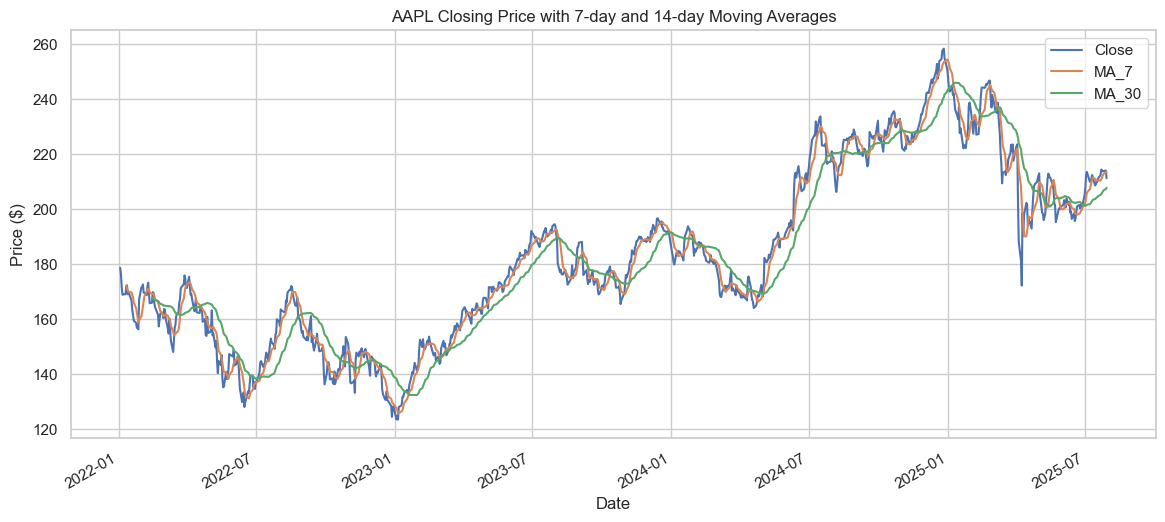

In [5]:
df = pd.read_sql("SELECT Date, Close, MA_7, MA_30 FROM stock_data WHERE Ticker = 'AAPL' ORDER BY Date", conn)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df[["Close", "MA_7", "MA_30"]].plot(title="AAPL Closing Price with 7-day and 14-day Moving Averages")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.show()

## 📊 Distribution of Daily Volatility

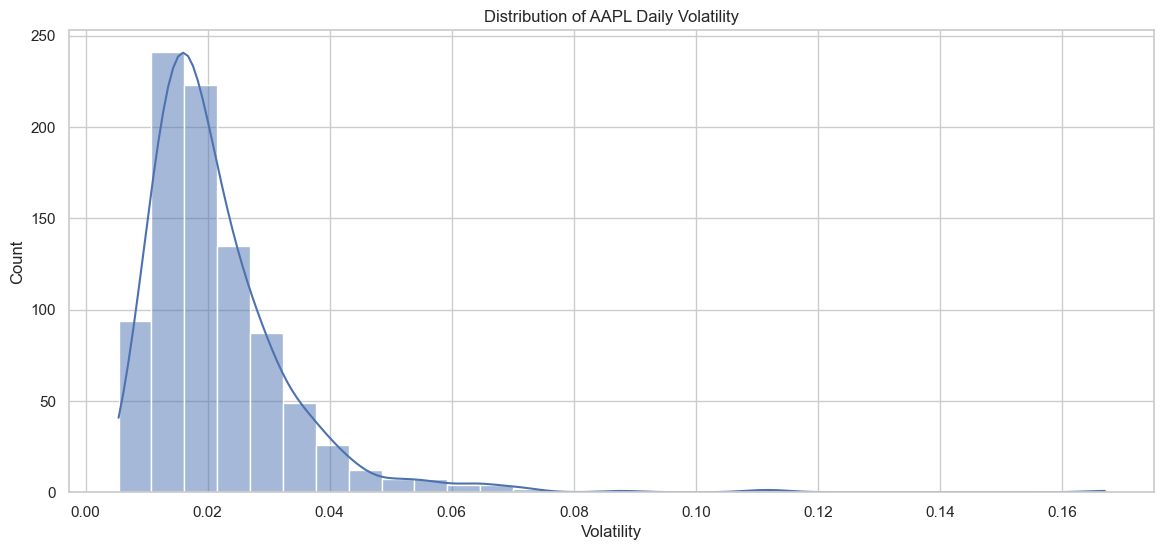

In [6]:
df_vol = pd.read_sql("SELECT Volatility FROM stock_data WHERE Ticker = 'AAPL' AND Volatility IS NOT NULL", conn)
sns.histplot(df_vol["Volatility"], bins=30, kde=True)
plt.title("Distribution of AAPL Daily Volatility")
plt.xlabel("Volatility")
plt.show()

## 📈 Price Signals Based on Moving Averages

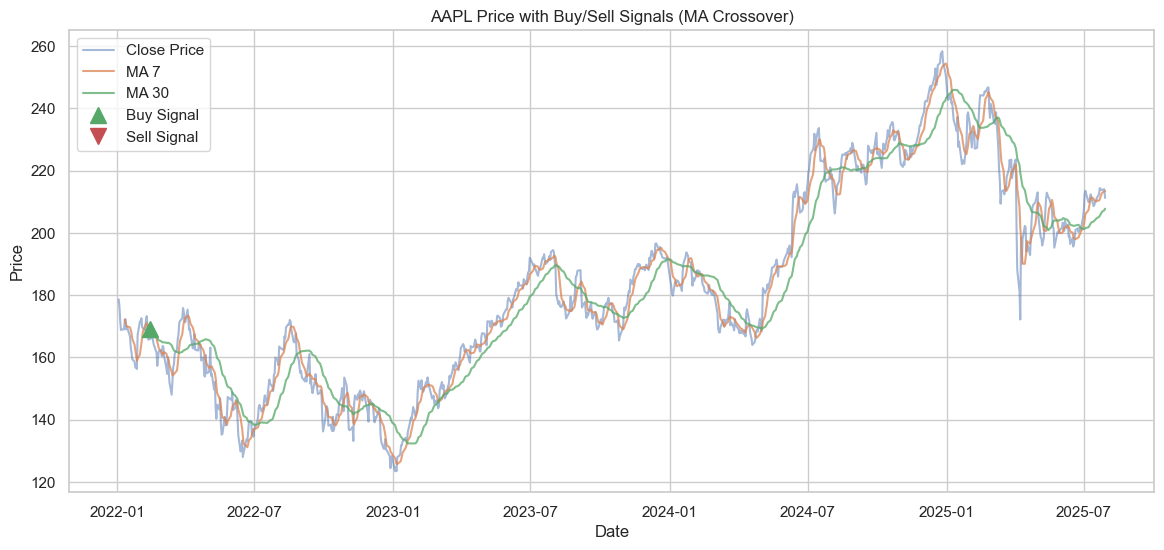

In [11]:
df_signals = df.copy()
df_signals["Signal"] = 0

# Use .loc to avoid chained assignment warnings
df_signals.loc[df_signals["MA_7"] > df_signals["MA_30"], "Signal"] = 1
df_signals.loc[df_signals["MA_7"] < df_signals["MA_30"], "Signal"] = -1

df_signals["Position"] = df_signals["Signal"].diff()

# Plotting
plt.plot(df_signals.index, df_signals["Close"], label="Close Price", alpha=0.5)
plt.plot(df_signals.index, df_signals["MA_7"], label="MA 7", alpha=0.75)
plt.plot(df_signals.index, df_signals["MA_30"], label="MA 30", alpha=0.75)

# Buy signal
plt.plot(
    df_signals[df_signals["Position"] == 1].index,
    df_signals.loc[df_signals["Position"] == 1, "MA_7"],
    "^", markersize=12, color='g', label="Buy Signal"
)

# Sell signal
plt.plot(
    df_signals[df_signals["Position"] == -1].index,
    df_signals.loc[df_signals["Position"] == -1, "MA_7"],
    "v", markersize=12, color='r', label="Sell Signal"
)

plt.title("AAPL Price with Buy/Sell Signals (MA Crossover)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## 📅 Latest Entry Timestamp

In [12]:
pd.read_sql("""
SELECT MAX(load_timestamp) AS last_loaded, COUNT(*) AS total_rows
FROM stock_data
WHERE Ticker = 'AAPL';
""", conn)

,last_loaded,total_rows
0,2025-07-30T18:09:23.688587,895


## ✅ Close connection

In [13]:
conn.close()